CONTENTS:
- [Imports](#imports)
- [Authenticate GitHub Client](#authenticate-github-client)
- [Pre-feth all the data from Jan 2025 in cache](#pre-feth-all-the-data-from-jan-2025-in-cache)
- [Full Time Evaluation](#full-time-evaluation)
- [Compare Full time contributors total performance across all repos since last 1 months](#compare-full-time-contributors-total-performance-across-all-repos-since-last-1-months)
- [Performance Evaluation - FullTime - Last 1 Months (based on Issues and PRs closed)](#performance-evaluation---fulltime---last-1-months-(based-on-issues-and-prs-closed))
- [Compare Full time contributors total performance across all repos since last 3 months](#compare-full-time-contributors-total-performance-across-all-repos-since-last-3-months)
- [Performance Evaluation - FullTime - Last 3 Months (based on Issues and PRs closed)](#performance-evaluation---fulltime---last-3-months-(based-on-issues-and-prs-closed))
- [Compare Full time contributors total performance across all repos since last Jan 2025](#compare-full-time-contributors-total-performance-across-all-repos-since-last-jan-2025)
- [Performance Evaluation - FullTime - Since Jan 2025 (based on Issues and PRs closed)](#performance-evaluation---fulltime---since-jan-2025-(based-on-issues-and-prs-closed))

<a name='imports'></a>
# Imports

In [1]:
!sudo /bin/bash -c "(source /venv/bin/activate; pip install --quiet jupyterlab-vim PyGithub)"
!jupyter labextension enable

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import datetime
import logging
import os

import github_utils

In [4]:
# Enable logging.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

<a name='authenticate-github-client'></a>
# Authenticate GitHub Client

In [51]:
os.environ["GITHUB_ACCESS_TOKEN"] = "*"

In [6]:
access_token = os.getenv("GITHUB_ACCESS_TOKEN")
if not access_token:
    _LOG.error("GITHUB_ACCESS_TOKEN not set. Exiting.")
    raise ValueError("Set GITHUB_ACCESS_TOKEN environment variable")
client = github_utils.GitHubAPI(access_token=access_token).get_client()

In [7]:
users = github_utils.get_github_contributors(
    client, repo_names=["causify-ai/cmamp"]
)
print(users)

{'causify-ai/cmamp': ['gpsaggese', 'gitpaulsmith', 'DanilYachmenev', 'rheenina', 'jsmerix', 'PomazkinG', 'gad26032', 'plyq', 'Shayawnn', 'sonaalKant', 'Sameep2808', 'tamriq', 'heanhsok', 'mongolianjesus', 'dremdem', 'sonniki', 'samarth9008', 'mindfreakthemon', 'Vedanshu7', 'pavolrabatin', 'max-rsrch', 'amrawadk', 'Jd8111997', 'alinakhay', 'Tsallagov', 'katerynak', 'aish-nidhi', 'jayati1397', 'elforeee', 'k0nsta', 'neha2801-create', 'Shaunak01', 'why2000', 'lizvladi', 'Vitaly-Protasov', 'OlgaVakhonina', 'tuimazy2008', 'enotdima', 'zet694', 'daberezina', 'jserebr', 'tkpratardan', 'pavel-particle', 'cma0416', 'k911mipt', 'LibertasSpZ', 'RichardProchadzka', 'andsilver', 'vvandriichuk']}


In [8]:
active_users_total = [
    "gpsaggese",
    "tkpratardan",
    "Shaunak01",
    "sonniki",
    "heanhsok",
    "Shayawnn",
    "rheenina",
    "PomazkinG",
    "gitpaulsmith",
    "samarth9008",
    "Vedanshu7",
    "dremdem",
    "cma0416",
    "tamriq",
    "mongolianjesus",
    "DanilYachmenev",
]

<a name='pre-feth-all-the-data-from-jan-2025-in-cache'></a>
# Pre-feth all the data from Jan 2025 in cache

In [9]:
# Use a long window for caching and a narrow slice for final analysis.
period_full = github_utils.utc_period("2025-01-01", "2025-10-01")

In [10]:
repos = [
    "helpers",
    "tutorials",
    "cmamp",
    "kaizenflow",
    "orange",
    "sports_analytics",
    "csfy",
]
org = "causify-ai"

In [12]:
github_utils.prefetch_periodic_user_repo_data(
    client, org, repos, active_users_total, period_full
)

Prefetching user-repo data:  13%|████████████████▌                                                                                                           | 15/112 [00:00<00:00, 140.65it/s]

helpers/gpsaggese: 85 commits, 74 PRs, 85 LOC entries, 23 issues assigned, 5 closed, 0 issue comments, 0 PR reviews
helpers/tkpratardan: 9 commits, 10 PRs, 9 LOC entries, 7 issues assigned, 1 closed, 0 issue comments, 0 PR reviews
helpers/Shaunak01: 44 commits, 51 PRs, 44 LOC entries, 57 issues assigned, 49 closed, 0 issue comments, 0 PR reviews
helpers/sonniki: 52 commits, 53 PRs, 52 LOC entries, 44 issues assigned, 38 closed, 0 issue comments, 0 PR reviews
helpers/heanhsok: 103 commits, 110 PRs, 103 LOC entries, 57 issues assigned, 40 closed, 0 issue comments, 0 PR reviews
helpers/Shayawnn: 0 commits, 0 PRs, 0 LOC entries, 3 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
helpers/rheenina: 1 commits, 1 PRs, 1 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
helpers/PomazkinG: 0 commits, 3 PRs, 0 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
helpers/gitpaulsmith: 1 commits, 1 PRs, 1 LOC entries, 0 issues assigned, 0 closed, 

Prefetching user-repo data:  39%|████████████████████████████████████████████████▋                                                                           | 44/112 [00:00<00:00, 131.65it/s]

tutorials/cma0416: 0 commits, 0 PRs, 0 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
tutorials/tamriq: 0 commits, 0 PRs, 0 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
tutorials/mongolianjesus: 0 commits, 0 PRs, 0 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
tutorials/DanilYachmenev: 0 commits, 0 PRs, 0 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
cmamp/gpsaggese: 17 commits, 13 PRs, 17 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
cmamp/tkpratardan: 6 commits, 30 PRs, 6 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
cmamp/Shaunak01: 9 commits, 55 PRs, 9 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
cmamp/sonniki: 16 commits, 52 PRs, 16 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
cmamp/heanhsok: 117 commits, 157 PRs, 117 LOC entries, 0 issues assigned, 0 closed, 0 issue

Prefetching user-repo data:  65%|████████████████████████████████████████████████████████████████████████████████▊                                           | 73/112 [00:00<00:00, 138.61it/s]

kaizenflow/gitpaulsmith: 1 commits, 1 PRs, 1 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
kaizenflow/samarth9008: 0 commits, 0 PRs, 0 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
kaizenflow/Vedanshu7: 0 commits, 0 PRs, 0 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
kaizenflow/dremdem: 0 commits, 0 PRs, 0 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
kaizenflow/cma0416: 0 commits, 0 PRs, 0 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
kaizenflow/tamriq: 0 commits, 0 PRs, 0 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
kaizenflow/mongolianjesus: 0 commits, 0 PRs, 0 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
kaizenflow/DanilYachmenev: 0 commits, 0 PRs, 0 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
orange/gpsaggese: 5 commits, 0 PRs, 5 LOC entries, 0 issues assigned, 0 

Prefetching user-repo data: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 112/112 [00:00<00:00, 136.13it/s]
INFO:github_utils:Prefetched 112 user-repo combos in 0.83 seconds for period 2025-01-01 00:00:00+00:00 to 2025-10-01 00:00:00+00:00.


sports_analytics/rheenina: 0 commits, 0 PRs, 0 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
sports_analytics/PomazkinG: 0 commits, 0 PRs, 0 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
sports_analytics/gitpaulsmith: 0 commits, 0 PRs, 0 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
sports_analytics/samarth9008: 0 commits, 0 PRs, 0 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
sports_analytics/Vedanshu7: 0 commits, 0 PRs, 0 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
sports_analytics/dremdem: 0 commits, 0 PRs, 0 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
sports_analytics/cma0416: 0 commits, 0 PRs, 0 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
sports_analytics/tamriq: 0 commits, 0 PRs, 0 LOC entries, 0 issues assigned, 0 closed, 0 issue comments, 0 PR reviews
sports_analytics/mongolianjesus: 0 

<a name='full-time-evaluation'></a>
# Full Time Evaluation

In [17]:
combined_df_fulltime = github_utils.collect_all_metrics(
    client, org, repos, active_users_total, period_full
)

INFO:github_utils:Processing 1/112: helpers/gpsaggese
INFO:github_utils:Processing 2/112: helpers/tkpratardan
INFO:github_utils:Processing 3/112: helpers/Shaunak01
INFO:github_utils:Processing 4/112: helpers/sonniki
INFO:github_utils:Processing 5/112: helpers/heanhsok
INFO:github_utils:Processing 6/112: helpers/Shayawnn
INFO:github_utils:Processing 7/112: helpers/rheenina
INFO:github_utils:Processing 8/112: helpers/PomazkinG
INFO:github_utils:Processing 9/112: helpers/gitpaulsmith
INFO:github_utils:Processing 10/112: helpers/samarth9008
INFO:github_utils:Processing 11/112: helpers/Vedanshu7
INFO:github_utils:Processing 12/112: helpers/dremdem
INFO:github_utils:Processing 13/112: helpers/cma0416
INFO:github_utils:Processing 14/112: helpers/tamriq
INFO:github_utils:Processing 15/112: helpers/mongolianjesus
INFO:github_utils:Processing 16/112: helpers/DanilYachmenev
INFO:github_utils:Processing 17/112: tutorials/gpsaggese
INFO:github_utils:Processing 18/112: tutorials/tkpratardan
INFO:git

In [18]:
if "issue_comments" not in combined_df_fulltime.columns:
    combined_df_fulltime["issue_comments"] = 0
if "pr_reviews" not in combined_df_fulltime.columns:
    combined_df_fulltime["pr_reviews"] = 0

<a name='compare-full-time-contributors-total-performance-across-all-repos-since-last-1-months'></a>
# Compare Full time contributors total performance across all repos since last 1 months

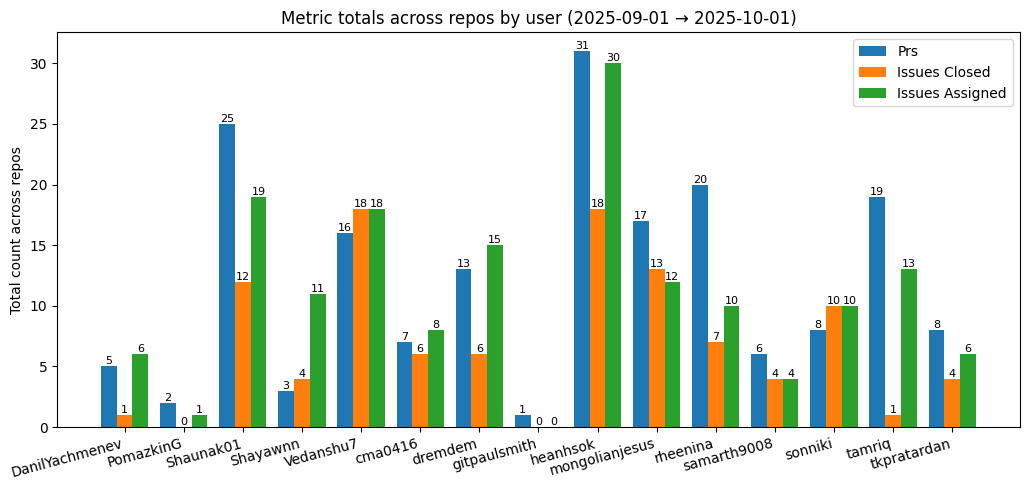

In [45]:
github_utils.plot_multi_metrics_totals_by_user(
    combined=combined_df_fulltime,
    metrics=["prs", "issues_closed", "issues_assigned"],
    users=active_users_total,
    repos=repos,
    start=datetime.datetime(2025, 9, 1),
    end=datetime.datetime(2025, 10, 1),
)

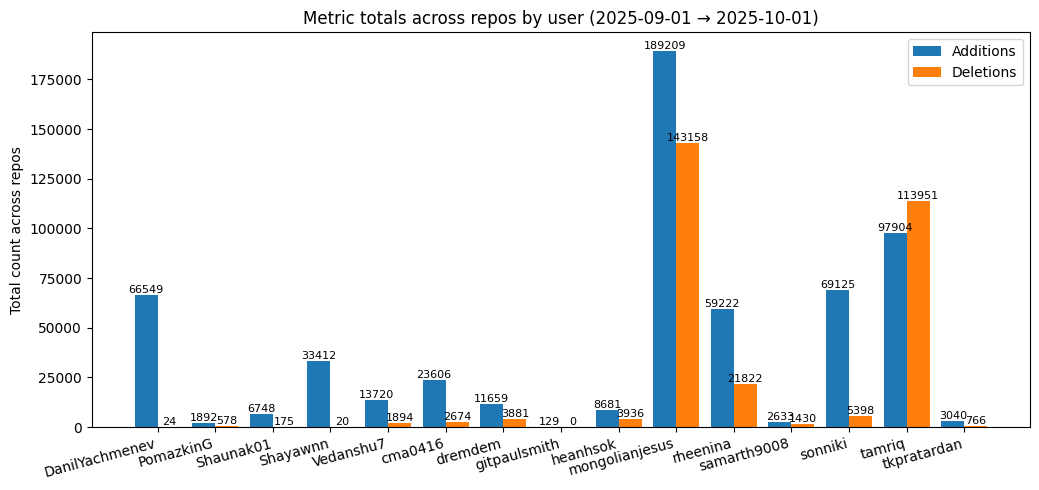

In [46]:
github_utils.plot_multi_metrics_totals_by_user(
    combined=combined_df_fulltime,
    metrics=["additions", "deletions"],
    users=[u for u in active_users_total if u != "gpsaggese"],
    repos=repos,
    start=datetime.datetime(2025, 9, 1),
    end=datetime.datetime(2025, 10, 1),
)

<a name='performance-evaluation---fulltime---last-1-months-(based-on-issues-and-prs-closed)'></a>
# Performance Evaluation - FullTime - Last 1 Months (based on Issues and PRs closed)

,prs_pctile,issues_closed_pctile
user,,
DanilYachmenev,0.27,0.23
PomazkinG,0.13,0.10
Shaunak01,0.93,0.80
Shayawnn,0.20,0.40
Vedanshu7,0.67,0.97
cma0416,0.40,0.57
dremdem,0.60,0.57
gitpaulsmith,0.07,0.10
heanhsok,1.00,0.97


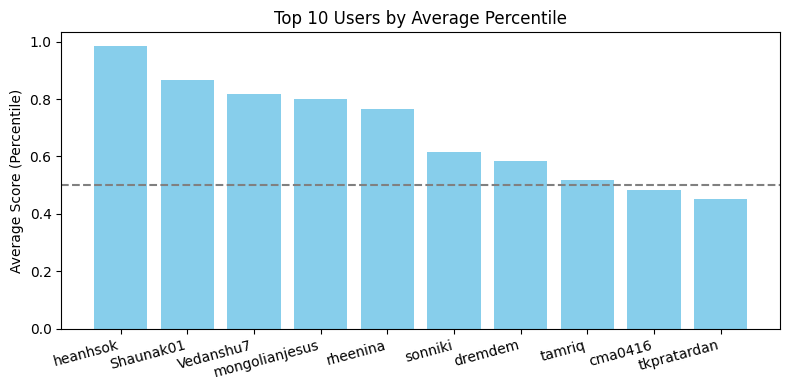

In [41]:
combined_df_fulltime_1 = github_utils.slice_by_date(
    combined_df_fulltime, "2025. 9, 1", "2025, 10, 1"
)
metrics = ["prs", "issues_closed"]
summary_users_fulltime = github_utils.summarize_users_across_repos(
    combined_df_fulltime_1, users=active_users_total, repos=repos
)
stats = github_utils.compute_percentile_ranks(summary_users_fulltime, metrics)
github_utils.visualize_user_metric_comparison(
    stats, score_type="percentile", top_n=10
)

<a name='compare-full-time-contributors-total-performance-across-all-repos-since-last-3-months'></a>
# Compare Full time contributors total performance across all repos since last 3 months

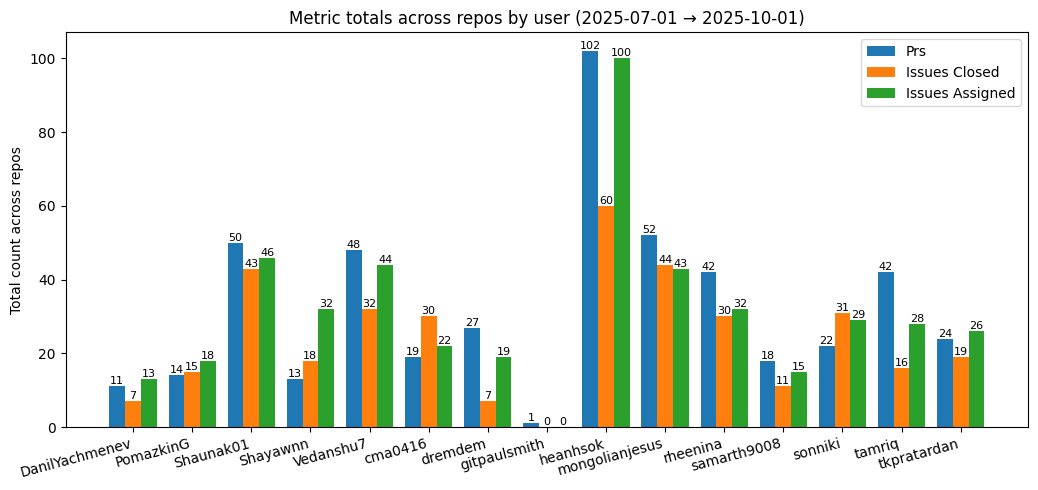

In [42]:
github_utils.plot_multi_metrics_totals_by_user(
    combined=combined_df_fulltime,
    metrics=["prs", "issues_closed", "issues_assigned"],
    users=active_users_total,
    repos=repos,
    start=datetime.datetime(2025, 7, 1),
    end=datetime.datetime(2025, 10, 1),
)

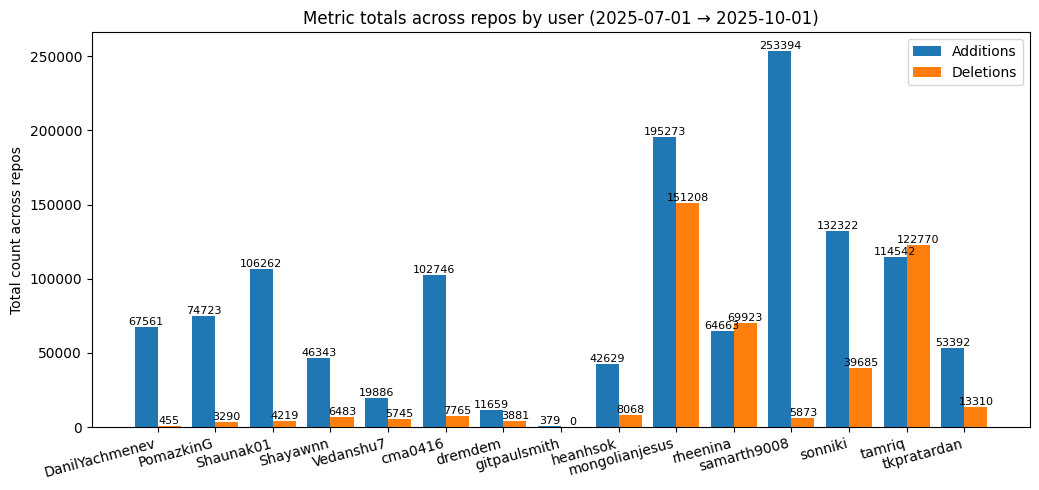

In [43]:
github_utils.plot_multi_metrics_totals_by_user(
    combined=combined_df_fulltime,
    metrics=["additions", "deletions"],
    users=active_users_total,
    repos=repos,
    start=datetime.datetime(2025, 7, 1),
    end=datetime.datetime(2025, 10, 1),
)

<a name='performance-evaluation---fulltime---last-3-months-(based-on-issues-and-prs-closed)'></a>
# Performance Evaluation - FullTime - Last 3 Months (based on Issues and PRs closed)

,prs_pctile,issues_closed_pctile
user,,
DanilYachmenev,0.13,0.17
PomazkinG,0.27,0.33
Shaunak01,0.87,0.87
Shayawnn,0.20,0.47
Vedanshu7,0.80,0.80
cma0416,0.40,0.63
dremdem,0.60,0.17
gitpaulsmith,0.07,0.07
heanhsok,1.00,1.00


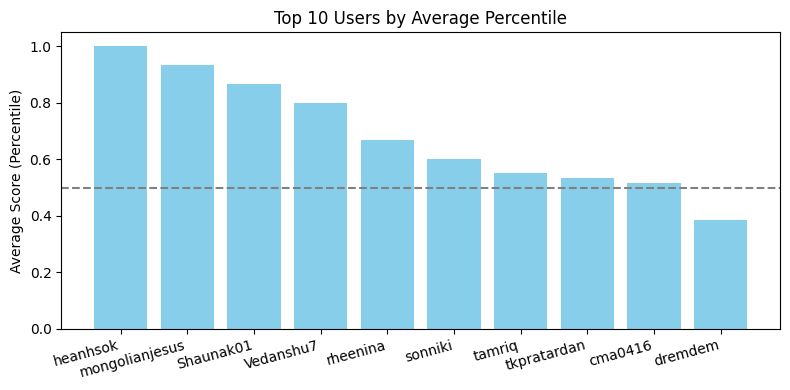

In [44]:
combined_df_fulltime_3 = github_utils.slice_by_date(
    combined_df_fulltime, "2025. 7, 1", "2025, 10, 1"
)
metrics = ["prs", "issues_closed"]
summary_users_fulltime_3 = github_utils.summarize_users_across_repos(
    combined_df_fulltime_3, users=active_users_total, repos=repos
)
stats_3 = github_utils.compute_percentile_ranks(summary_users_fulltime_3, metrics)
github_utils.visualize_user_metric_comparison(
    stats_3, score_type="percentile", top_n=10
)

<a name='compare-full-time-contributors-total-performance-across-all-repos-since-last-jan-2025'></a>
# Compare Full time contributors total performance across all repos since last Jan 2025

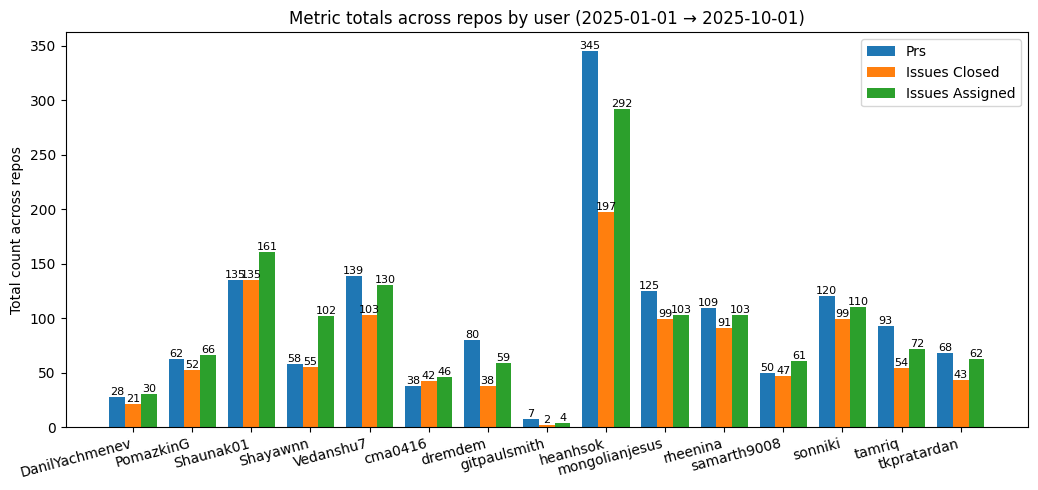

In [47]:
github_utils.plot_multi_metrics_totals_by_user(
    combined=combined_df_fulltime,
    metrics=["prs", "issues_closed", "issues_assigned"],
    users=active_users_total,
    repos=repos,
    start=datetime.datetime(2025, 1, 1),
    end=datetime.datetime(2025, 10, 1),
)

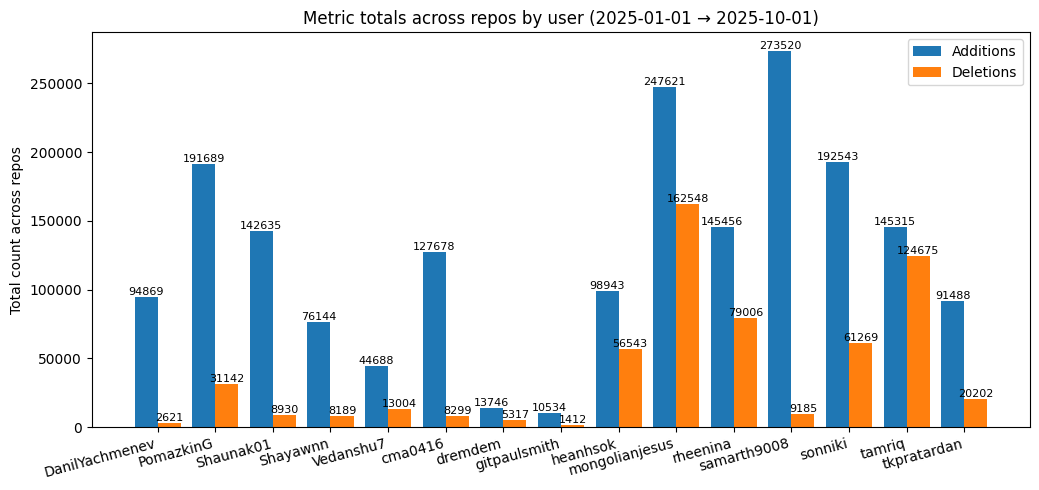

In [48]:
github_utils.plot_multi_metrics_totals_by_user(
    combined=combined_df_fulltime,
    metrics=["additions", "deletions"],
    users=active_users_total,
    repos=repos,
    start=datetime.datetime(2025, 1, 1),
    end=datetime.datetime(2025, 10, 1),
)

<a name='performance-evaluation---fulltime---since-jan-2025-(based-on-issues-and-prs-closed)'></a>
# Performance Evaluation - FullTime - Since Jan 2025 (based on Issues and PRs closed)

,prs_pctile,issues_closed_pctile
user,,
DanilYachmenev,0.13,0.13
PomazkinG,0.40,0.47
Shaunak01,0.87,0.93
Shayawnn,0.33,0.60
Vedanshu7,0.93,0.87
cma0416,0.20,0.27
dremdem,0.53,0.20
gitpaulsmith,0.07,0.07
heanhsok,1.00,1.00


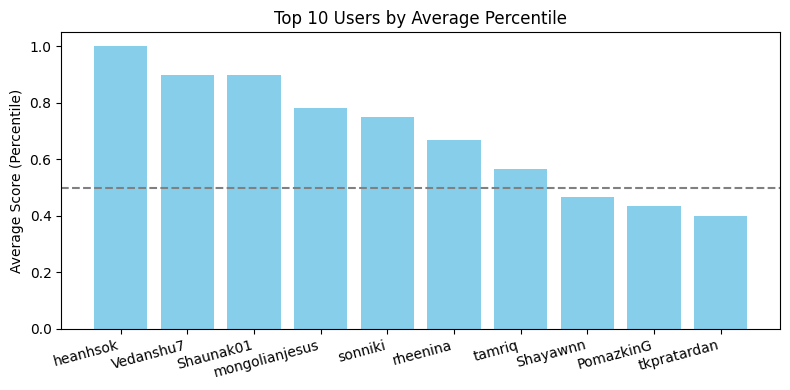

In [50]:
combined_df_fulltime_jan = github_utils.slice_by_date(
    combined_df_fulltime, "2025, 1, 1", "2025, 10, 1"
)
metrics = ["prs", "issues_closed"]
summary_users_fulltime_jan = github_utils.summarize_users_across_repos(
    combined_df_fulltime_jan, users=active_users_total, repos=repos
)
stats_jan = github_utils.compute_percentile_ranks(
    summary_users_fulltime_jan, metrics
)
github_utils.visualize_user_metric_comparison(
    stats_jan, score_type="percentile", top_n=10
)